# Comparative entropy analysis of BRCA-associated genes

This notebook implements a reproducible pipeline for extracting exon and
intron regions from GenBank annotations and comparing their topological
entropy across human, chimpanzee and mouse orthologs.

The project is based on my graduation research at the Faculty of Physics,
Lomonosov Moscow State University.

## 1. Research question

Can topological entropy methods identify structural differences between
exons and introns of orthologous genes, and how strongly are the estimates
affected by sequence length?

## 2. Environment setup

Install the external dependency required for reading GenBank annotations.

In [1]:
%pip install -q biopython

## 3. Imports and project configuration

In [2]:
from collections import Counter
from pathlib import Path
import copy
import math

from Bio import SeqIO
from Bio.SeqFeature import FeatureLocation, SeqFeature
from Bio.SeqRecord import SeqRecord
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr


In [3]:
# Resolve project directories both from the repository root
# and from the notebooks directory.

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Input data directory: {DATA_DIR}")


Project root: /content
Input data directory: /content/data/raw


## 4. Dataset configuration

The analysis includes four BRCA-associated genes in three mammalian species.
The configuration below fixes the input filename and transcript model for each
gene–species combination, making the analysis reproducible.


In [4]:
SPECIES = {
    "hs": "Homo sapiens",
    "pt": "Pan troglodytes",
    "mm": "Mus musculus",
}

TRANSCRIPTS = {
    "BRCA1": {
        "hs": "NM_007294.3",
        "pt": "NM_001045493.1",
        "mm": "NM_009764.3",
    },
    "BRCA2": {
        "hs": "NM_000059.3",
        "pt": "XM_016925134.4",
        "mm": "NM_001081001.2",
    },
    "PALB2": {
        "hs": "NM_024675.3",
        "pt": "XM_063796860.1",
        "mm": "NM_001081238.2",
    },
    "BARD1": {
        "hs": "NM_000465.4",
        "pt": "XM_526019.7",
        "mm": "NM_007525.3",
    },
}

In [5]:
DATASETS = [
    {
        "species": SPECIES[species_code],
        "species_code": species_code,
        "gene": gene,
        "file": f"{species_code}_{gene}_gb.gb",
        "transcript_id": transcript_id,
    }
    for gene, species_transcripts in TRANSCRIPTS.items()
    for species_code, transcript_id in species_transcripts.items()
]

datasets_df = pd.DataFrame(DATASETS)
datasets_df

,species,species_code,gene,file,transcript_id
0,Homo sapiens,hs,BRCA1,hs_BRCA1_gb.gb,NM_007294.3
1,Pan troglodytes,pt,BRCA1,pt_BRCA1_gb.gb,NM_001045493.1
2,Mus musculus,mm,BRCA1,mm_BRCA1_gb.gb,NM_009764.3
3,Homo sapiens,hs,BRCA2,hs_BRCA2_gb.gb,NM_000059.3
4,Pan troglodytes,pt,BRCA2,pt_BRCA2_gb.gb,XM_016925134.4
5,Mus musculus,mm,BRCA2,mm_BRCA2_gb.gb,NM_001081001.2
6,Homo sapiens,hs,PALB2,hs_PALB2_gb.gb,NM_024675.3
7,Pan troglodytes,pt,PALB2,pt_PALB2_gb.gb,XM_063796860.1
8,Mus musculus,mm,PALB2,mm_PALB2_gb.gb,NM_001081238.2
9,Homo sapiens,hs,BARD1,hs_BARD1_gb.gb,NM_000465.4


### Input file check

The notebook expects the 12 GenBank files listed below in `data/raw`.
This check does not stop the notebook while the functions are being reviewed,
but the batch-processing section requires all files to be present.


In [6]:
from google.colab import files

DATA_DIR.mkdir(parents=True, exist_ok=True)

expected_names = {
    dataset["file"]
    for dataset in DATASETS
}

existing_names = {
    path.name
    for path in DATA_DIR.iterdir()
    if path.is_file()
}

missing_names = expected_names - existing_names

if not missing_names:
    print("All input files are already available. Upload skipped.")

else:
    print(f"{len(missing_names)} input file(s) are missing.")
    print("Select the GenBank files in the upload dialog.")

    uploaded_files = files.upload()

    saved_files = []
    unexpected_files = []

    for filename, content in uploaded_files.items():
        safe_filename = Path(filename).name

        if safe_filename in expected_names:
            target_path = DATA_DIR / safe_filename
            target_path.write_bytes(content)
            saved_files.append(safe_filename)
        else:
            unexpected_files.append(safe_filename)

    print(f"\nSaved {len(saved_files)} file(s) to:")
    print(DATA_DIR)

    if unexpected_files:
        print("\nFiles with unexpected names were not saved:")
        for filename in unexpected_files:
            print(f"  - {filename}")

All input files are already available. Upload skipped.


In [7]:
expected_files = [
    DATA_DIR / dataset["file"]
    for dataset in DATASETS
]

missing_files = [
    path.name
    for path in expected_files
    if not path.exists()
]

if missing_files:
    print(
        f"{len(missing_files)} input file(s) are currently missing."
    )
    print(
        "Place the GenBank files in data/raw before running "
        "the batch-processing section."
    )
    display(
        pd.DataFrame(
            {"missing_file": missing_files}
        )
    )
else:
    print("All 12 input GenBank files were found.")


All 12 input GenBank files were found.


## 5. GenBank annotation helpers

The following helper functions read gene, transcript and protein identifiers
from GenBank feature qualifiers.

In [8]:
def get_gene_name(feature):
    """Return the primary gene symbol stored in a GenBank feature."""

    gene_name = feature.qualifiers.get("gene", [""])[0]

    if gene_name:
        return gene_name

    gene_synonyms = feature.qualifiers.get(
        "gene_synonym",
        [""],
    )[0]

    return gene_synonyms.split(";")[0].strip()


def get_acc(feature):
    """Return the transcript accession stored in a GenBank feature."""

    return feature.qualifiers.get(
        "transcript_id",
        [""],
    )[0]


def get_protein_id(feature):
    """Return the protein accession stored in a GenBank feature."""

    return feature.qualifiers.get(
        "protein_id",
        [""],
    )[0]


def feature_len(feature, sequence):
    """Return the spliced length of a GenBank feature."""

    return len(feature.extract(sequence))


## 6. Representative transcript selection

For each gene, mRNA features are matched with their corresponding CDS
features. Curated RefSeq transcripts are prioritized, followed by CDS length
and total mRNA length.

If a transcript identifier is specified in the dataset configuration, the
function selects that transcript explicitly to ensure reproducibility.

In [9]:
def select_representative_transcript(
    gene_features,
    sequence,
    preferred_transcript_id=None,
    verbose=True,
):
    """
    Select one representative mRNA/CDS pair for a gene.

    Parameters
    ----------
    gene_features : list
        GenBank features associated with the selected gene.

    sequence : Bio.Seq.Seq
        Genomic sequence used to calculate feature lengths.

    preferred_transcript_id : str or None, optional
        Transcript identifier selected in advance.
        If provided, only the matching mRNA model is considered.

    verbose : bool, optional
        If True, print information about the selected transcript.

    Returns
    -------
    dict
        Information about the selected mRNA/CDS pair, including
        transcript ID, protein ID, lengths and feature objects.

    Raises
    ------
    ValueError
        If no suitable mRNA/CDS pair can be found.
    """

    def normalize_accession(accession):
        """Remove the version suffix from an accession identifier."""
        if not accession:
            return ""
        return accession.split(".")[0]

    mrnas = [
        feature
        for feature in gene_features
        if feature.type == "mRNA"
    ]

    cdss = [
        feature
        for feature in gene_features
        if feature.type == "CDS"
    ]

    if not mrnas:
        raise ValueError(
            "No mRNA features were found for the selected gene."
        )

    if not cdss:
        raise ValueError(
            "No CDS features were found for the selected gene."
        )

    # Restrict the analysis to the predefined transcript model
    # when a preferred transcript identifier is provided.
    if preferred_transcript_id is not None:
        preferred_normalized = normalize_accession(
            preferred_transcript_id
        )

        mrnas = [
            mrna
            for mrna in mrnas
            if normalize_accession(get_acc(mrna))
            == preferred_normalized
        ]

        if not mrnas:
            raise ValueError(
                f"Preferred transcript "
                f"{preferred_transcript_id} was not found."
            )

    candidates = []

    for mrna in mrnas:
        mrna_accession = get_acc(mrna) or ""
        mrna_normalized = normalize_accession(mrna_accession)

        linked_cds = []

        for cds in cdss:
            cds_transcript = cds.qualifiers.get(
                "transcript_id",
                [""],
            )[0]

            cds_normalized = normalize_accession(cds_transcript)

            # Use transcript identifiers when both features contain them.
            if cds_normalized and mrna_normalized:
                same_transcript = (
                    cds_normalized == mrna_normalized
                )

            # Fall back to coordinate containment when an identifier
            # is unavailable.
            else:
                same_transcript = (
                    int(cds.location.start)
                    >= int(mrna.location.start)
                    and int(cds.location.end)
                    <= int(mrna.location.end)
                )

            if same_transcript:
                linked_cds.append(cds)

        # Skip mRNA features that cannot be linked to a CDS.
        if not linked_cds:
            continue

        # Select the longest linked CDS for this transcript.
        best_cds = max(
            linked_cds,
            key=lambda feature: feature_len(
                feature,
                sequence,
            ),
        )

        candidates.append(
            {
                "mrna": mrna,
                "cds": best_cds,
                "transcript_id": mrna_accession,
                "protein_id": get_protein_id(best_cds),
                "mrna_len": feature_len(
                    mrna,
                    sequence,
                ),
                "cds_len": feature_len(
                    best_cds,
                    sequence,
                ),
                "is_refseq_nm": mrna_accession.startswith(
                    "NM_"
                ),
                "is_predicted_xm": mrna_accession.startswith(
                    "XM_"
                ),
            }
        )

    if not candidates:
        raise ValueError(
            "No suitable mRNA/CDS pair was found for "
            "the selected gene."
        )

    # Prioritize curated RefSeq transcripts, followed by
    # CDS length and total mRNA length.
    candidates.sort(
        key=lambda candidate: (
            candidate["is_refseq_nm"],
            candidate["cds_len"],
            candidate["mrna_len"],
        ),
        reverse=True,
    )

    selected = candidates[0]

    if verbose:
        print(f"mRNA features found: {len(mrnas)}")
        print(f"CDS features found: {len(cdss)}")
        print(f"Valid candidates: {len(candidates)}")
        print()
        print(
            "Selected transcript:",
            selected["transcript_id"],
        )
        print(
            "Selected protein:",
            selected["protein_id"],
        )
        print(
            "mRNA length:",
            selected["mrna_len"],
        )
        print(
            "CDS length:",
            selected["cds_len"],
        )
        print(
            "mRNA location:",
            selected["mrna"].location,
        )
        print(
            "CDS location:",
            selected["cds"].location,
        )

    return selected

## 7. Transcript-defined locus and region extraction

The genomic locus is defined from the first to the last exon of the selected
transcript rather than from the complete gene annotation.

A new sequence record is created for this locus. Exons and introns are then
extracted in locus-relative coordinates. Region numbers follow the biological
transcript direction, including genes located on the reverse strand.

In [10]:
def build_transcript_locus(
    record,
    gene_features,
    selected_transcript,
    gene_name,
    species_name,
    orient_sequences_to_transcript=True,
    verbose=True,
):
    """
    Create a transcript-defined genomic locus and extract its exons and introns.

    The locus is defined from the first to the last exon of the selected mRNA
    rather than from the complete gene feature.

    Parameters
    ----------
    record : Bio.SeqRecord.SeqRecord
        Original GenBank record containing the genomic sequence.

    gene_features : list
        GenBank features associated with the selected gene.

    selected_transcript : dict
        Result returned by `select_representative_transcript`.
        The dictionary must contain the selected `mrna` feature and may
        contain the corresponding `cds` feature.

    gene_name : str
        Gene symbol, for example `BRCA1`.

    species_name : str
        Full species name, for example `Homo sapiens`.

    orient_sequences_to_transcript : bool
        If True, sequences from reverse-strand genes are reverse-complemented
        so that exon and intron sequences follow the transcript direction.

    verbose : bool
        If True, print a summary of the extracted locus.

    Returns
    -------
    dict
        Dictionary containing:

        - `record`: transcript-defined SeqRecord
        - `exons`: list of exon dictionaries
        - `introns`: list of intron dictionaries
        - `summary`: locus-level metadata

    Raises
    ------
    ValueError
        If the selected transcript has no exon parts or if the calculated
        locus boundaries are invalid.
    """

    target_mrna = selected_transcript["mrna"]
    # Extract exon parts from the selected transcript location.
    transcript_parts = list(target_mrna.location.parts)

    if not transcript_parts:
        raise ValueError(
            "The selected transcript does not contain exon location parts."
        )

    # Sort exon parts by genomic coordinate.
    genomic_parts = sorted(
        transcript_parts,
        key=lambda part: int(part.start),
    )

    locus_start = min(
        int(part.start)
        for part in genomic_parts
    )

    locus_end = max(
        int(part.end)
        for part in genomic_parts
    )

    if locus_start < 0 or locus_end > len(record.seq):
        raise ValueError(
            "Transcript-defined locus boundaries are outside "
            "the original sequence."
        )

    if locus_start >= locus_end:
        raise ValueError(
            "Invalid transcript-defined locus boundaries."
        )

    strand = target_mrna.location.strand

    if strand not in (-1, 1):
        strand = 1

    locus_span_length = locus_end - locus_start

    spliced_mrna_length = sum(
        int(part.end) - int(part.start)
        for part in genomic_parts
    )

    intronic_length = (
        locus_span_length
        - spliced_mrna_length
    )

    # Create a new record containing only the transcript-defined locus.
    locus_sequence = record.seq[locus_start:locus_end]

    species_id = species_name.replace(" ", "_")

    locus_record = SeqRecord(
        locus_sequence,
        id=f"{species_id}_{gene_name}_locus",
        name=gene_name,
        description=(
            f"{species_name} {gene_name} "
            "transcript-defined genomic locus"
        ),
    )

    locus_record.annotations["molecule_type"] = (
        record.annotations.get("molecule_type", "DNA")
    )

    locus_record.annotations["organism"] = species_name

    # Transfer fully contained gene-related features.
    # Public location shifting is used instead of the private `_shift` method.
    shifted_features = []

    for feature in gene_features:
        if feature.location is None:
            continue

        feature_start = int(feature.location.start)
        feature_end = int(feature.location.end)

        fully_contained = (
            feature_start >= locus_start
            and feature_end <= locus_end
        )

        if not fully_contained:
            continue

        shifted_feature = copy.deepcopy(feature)

        shifted_feature.location = (
            feature.location + (-locus_start)
        )

        shifted_features.append(shifted_feature)

    # Add a locus-level gene feature if the original gene feature
    # was not fully contained within the transcript-defined interval.
    contains_gene_feature = any(
        feature.type == "gene"
        for feature in shifted_features
    )

    if not contains_gene_feature:
        locus_gene_feature = SeqFeature(
            FeatureLocation(
                0,
                locus_span_length,
                strand=strand,
            ),
            type="gene",
            qualifiers={
                "gene": [gene_name],
                "note": [
                    "Transcript-defined locus from the first "
                    "to the last exon"
                ],
            },
        )

        shifted_features.insert(
            0,
            locus_gene_feature,
        )

    locus_record.features = shifted_features

    # Determine transcript exon order.
    # For reverse-strand genes, biological transcript order is opposite
    # to genomic coordinate order.
    if strand == -1:
        parts_in_transcript_order = list(
            reversed(genomic_parts)
        )
    else:
        parts_in_transcript_order = genomic_parts

    transcript_number_by_coordinates = {
        (
            int(part.start),
            int(part.end),
        ): transcript_number
        for transcript_number, part in enumerate(
            parts_in_transcript_order,
            start=1,
        )
    }

    exons = []

    for genomic_order, part in enumerate(
        genomic_parts,
        start=1,
    ):
        absolute_start = int(part.start)
        absolute_end = int(part.end)

        relative_start = (
            absolute_start
            - locus_start
        )

        relative_end = (
            absolute_end
            - locus_start
        )

        transcript_number = (
            transcript_number_by_coordinates[
                (
                    absolute_start,
                    absolute_end,
                )
            ]
        )

        exon_sequence = locus_record.seq[
            relative_start:relative_end
        ]

        # Return exon sequences in biological transcript orientation.
        if (
            orient_sequences_to_transcript
            and strand == -1
        ):
            exon_sequence = (
                exon_sequence.reverse_complement()
            )

        exons.append(
            {
                "number": transcript_number,
                "genomic_order": genomic_order,
                "start": relative_start,
                "end": relative_end,
                "absolute_start": absolute_start,
                "absolute_end": absolute_end,
                "length": (
                    relative_end
                    - relative_start
                ),
                "strand": strand,
                "seq": str(exon_sequence),
            }
        )

    # Keep the list in genomic coordinate order for plotting
    # and intron boundary calculation.
    exons = sorted(
        exons,
        key=lambda exon: exon["start"],
    )

    introns = []

    for genomic_order in range(
        1,
        len(exons),
    ):
        left_exon = exons[genomic_order - 1]
        right_exon = exons[genomic_order]

        intron_start = left_exon["end"]
        intron_end = right_exon["start"]

        if intron_start >= intron_end:
            raise ValueError(
                "Overlapping or incorrectly ordered exon "
                "coordinates were detected."
            )

        exon_numbers = sorted(
            [
                left_exon["number"],
                right_exon["number"],
            ]
        )

        intron_number = exon_numbers[0]

        intron_sequence = locus_record.seq[
            intron_start:intron_end
        ]

        # Return intron sequences in biological transcript orientation.
        if (
            orient_sequences_to_transcript
            and strand == -1
        ):
            intron_sequence = (
                intron_sequence.reverse_complement()
            )

        introns.append(
            {
                "number": intron_number,
                "genomic_order": genomic_order,
                "between_exons": (
                    f"{exon_numbers[0]}-"
                    f"{exon_numbers[1]}"
                ),
                "start": intron_start,
                "end": intron_end,
                "absolute_start": (
                    intron_start
                    + locus_start
                ),
                "absolute_end": (
                    intron_end
                    + locus_start
                ),
                "length": (
                    intron_end
                    - intron_start
                ),
                "strand": strand,
                "seq": str(intron_sequence),
            }
        )

    summary = {
        "gene": gene_name,
        "species": species_name,
        "transcript_id": selected_transcript.get(
            "transcript_id"
        ),
        "protein_id": selected_transcript.get(
            "protein_id"
        ),
        "strand": strand,
        "locus_start": locus_start,
        "locus_end": locus_end,
        "locus_span_length": locus_span_length,
        "spliced_mrna_length": spliced_mrna_length,
        "intronic_length": intronic_length,
        "exon_count": len(exons),
        "intron_count": len(introns),
        "feature_count": len(
            locus_record.features
        ),
    }

    if verbose:
        strand_label = (
            "+"
            if strand == 1
            else "-"
        )

        print(
            f"{gene_name} transcript-defined locus:"
        )
        print(
            f"  Species: {species_name}"
        )
        print(
            "  Transcript:",
            summary["transcript_id"],
        )
        print(
            f"  Strand: {strand_label}"
        )
        print(
            f"  Original coordinates: "
            f"{locus_start}-{locus_end}"
        )
        print(
            f"  Locus span length: "
            f"{locus_span_length:,} bp"
        )
        print(
            f"  Spliced mRNA length: "
            f"{spliced_mrna_length:,} bp"
        )
        print(
            f"  Intronic length: "
            f"{intronic_length:,} bp"
        )
        print(
            f"  Exons: {len(exons)}"
        )
        print(
            f"  Introns: {len(introns)}"
        )
        print(
            f"  Transferred features: "
            f"{len(locus_record.features)}"
        )
        print(
            "  Feature types:",
            dict(
                Counter(
                    feature.type
                    for feature
                    in locus_record.features
                )
            ),
        )

    return {
        "record": locus_record,
        "exons": exons,
        "introns": introns,
        "summary": summary,
    }

## 8. Topological entropy calculation

Two sequence-complexity measures are calculated:

- Koslicki topological entropy;
- Jin generalized topological entropy.

For both methods, the maximum admissible word length is selected
automatically from the sequence length. Sequences that do not satisfy the
minimum length requirements are retained in the output table with an
appropriate processing status.

The same functions are applied to exon and intron sequences from all
gene–species combinations.

In [11]:
DNA_ALPHABET = frozenset("ACGT")


def _prepare_dna_sequence(sequence):
    """
    Convert a sequence to an uppercase DNA string and validate its alphabet.

    Whitespace is removed before validation.

    Parameters
    ----------
    sequence : str or Bio.Seq.Seq
        Input nucleotide sequence.

    Returns
    -------
    str
        Normalized DNA sequence.

    Raises
    ------
    ValueError
        If the sequence contains symbols other than A, C, G and T.
    """

    normalized_sequence = "".join(
        str(sequence).upper().split()
    )

    invalid_symbols = sorted(
        set(normalized_sequence) - DNA_ALPHABET
    )

    if invalid_symbols:
        symbols = ", ".join(invalid_symbols)

        raise ValueError(
            "The sequence contains unsupported symbols: "
            f"{symbols}. Only A, C, G and T are allowed."
        )

    return normalized_sequence


def _select_maximum_word_length(sequence_length):
    """
    Select the largest admissible word length for a finite DNA sequence.

    The selected integer n satisfies:

        4**n + n - 1 <= sequence_length

    Parameters
    ----------
    sequence_length : int
        Length of the input sequence.

    Returns
    -------
    int or None
        Maximum admissible word length, or None when the sequence
        is shorter than the minimum required length.
    """

    if sequence_length < 4:
        return None

    word_length = 1

    while (
        4 ** (word_length + 1)
        + (word_length + 1)
        - 1
        <= sequence_length
    ):
        word_length += 1

    return word_length


def _count_distinct_subwords(sequence, word_length):
    """
    Count distinct overlapping subwords of a specified length.

    Parameters
    ----------
    sequence : str
        DNA sequence.

    word_length : int
        Length of the subwords.

    Returns
    -------
    int
        Number of distinct overlapping subwords.
    """

    return len(
        {
            sequence[start:start + word_length]
            for start in range(
                len(sequence) - word_length + 1
            )
        }
    )

In [12]:
def koslicki_topological_entropy(sequence):
    """
    Calculate Koslicki topological entropy for a finite DNA sequence.

    The maximum admissible word length n is selected automatically
    according to:

        4**n + n - 1 <= L

    where L is the original sequence length.

    The entropy is calculated using the first:

        4**n + n - 1

    symbols of the sequence.

    Parameters
    ----------
    sequence : str or Bio.Seq.Seq
        Input DNA sequence.

    Returns
    -------
    dict
        Dictionary containing the entropy value, processing status,
        selected word length and calculation metadata.
    """

    sequence = _prepare_dna_sequence(sequence)
    original_length = len(sequence)

    word_length = _select_maximum_word_length(
        original_length
    )

    if word_length is None:
        return {
            "Htop": None,
            "status": "too_short_for_definition",
            "n": None,
            "original_length": original_length,
            "used_length": None,
            "p_w_n": None,
        }

    used_length = (
        4 ** word_length
        + word_length
        - 1
    )

    truncated_sequence = sequence[:used_length]

    distinct_subword_count = _count_distinct_subwords(
        truncated_sequence,
        word_length,
    )

    entropy = (
        math.log(distinct_subword_count, 4)
        / word_length
    )

    return {
        "Htop": entropy,
        "status": "ok",
        "n": word_length,
        "original_length": original_length,
        "used_length": used_length,
        "p_w_n": distinct_subword_count,
    }

In [13]:
def jin_generalized_topological_entropy(
    sequence,
    k=3,
):
    """
    Calculate Jin generalized topological entropy for a DNA sequence.

    The maximum admissible word length n_v is selected automatically
    according to:

        4**n_v + n_v - 1 <= L

    The generalized entropy is the mean contribution of k consecutive
    word lengths ending at n_v.

    Parameters
    ----------
    sequence : str or Bio.Seq.Seq
        Input DNA sequence.

    k : int, default=3
        Number of consecutive word lengths included in the calculation.
        The method requires k <= n_v.

    Returns
    -------
    dict
        Dictionary containing the generalized entropy value, processing
        status, selected parameters and calculation metadata.

    Raises
    ------
    ValueError
        If k is not a positive integer.
    """

    if (
        not isinstance(k, int)
        or isinstance(k, bool)
        or k < 1
    ):
        raise ValueError(
            "Parameter k must be a positive integer."
        )

    sequence = _prepare_dna_sequence(sequence)
    original_length = len(sequence)

    maximum_word_length = (
        _select_maximum_word_length(
            original_length
        )
    )

    if maximum_word_length is None:
        return {
            "HGtop": None,
            "status": "too_short_for_definition",
            "k": k,
            "n_v": None,
            "original_length": original_length,
            "used_length": None,
        }

    used_length = (
        4 ** maximum_word_length
        + maximum_word_length
        - 1
    )

    if k > maximum_word_length:
        return {
            "HGtop": None,
            "status": "k_greater_than_n_v",
            "k": k,
            "n_v": maximum_word_length,
            "original_length": original_length,
            "used_length": used_length,
        }

    truncated_sequence = sequence[:used_length]

    entropy_terms = []

    first_word_length = (
        maximum_word_length - k + 1
    )

    for word_length in range(
        first_word_length,
        maximum_word_length + 1,
    ):
        distinct_subword_count = (
            _count_distinct_subwords(
                truncated_sequence,
                word_length,
            )
        )

        entropy_term = (
            math.log(
                distinct_subword_count,
                4,
            )
            / word_length
        )

        entropy_terms.append(entropy_term)

    generalized_entropy = (
        sum(entropy_terms) / k
    )

    return {
        "HGtop": generalized_entropy,
        "status": "ok",
        "k": k,
        "n_v": maximum_word_length,
        "original_length": original_length,
        "used_length": used_length,
    }

In [14]:
def make_region_entropy_table(
    items,
    region_type,
    method="jin",
    k=3,
    metadata=None,
    invalid_symbol_policy="skip",
):
    """
    Build an entropy table for exon or intron sequences.

    Parameters
    ----------
    items : list of dict
        Extracted exon or intron records. Each item must contain
        a `seq` field and may contain coordinate metadata.

    region_type : str
        Region category, for example `exon` or `intron`.

    method : {"koslicki", "jin"}, default="jin"
        Entropy method used for the calculation.

    k : int, default=3
        Generalization parameter used by the Jin method.
        Ignored when method="koslicki".

    metadata : dict or None
        Optional dataset-level metadata added to every output row,
        such as gene, species and transcript ID.

    invalid_symbol_policy : {"skip", "raise"}, default="skip"
        Behaviour when a region contains symbols other than A, C, G and T.

    Returns
    -------
    pandas.DataFrame
        Region-level entropy results and processing metadata.
    """

    normalized_method = str(method).strip().lower()
    normalized_policy = str(
        invalid_symbol_policy
    ).strip().lower()

    if normalized_method not in {"koslicki", "jin"}:
        raise ValueError(
            "Unsupported entropy method. "
            "Expected 'koslicki' or 'jin'."
        )

    if normalized_policy not in {"skip", "raise"}:
        raise ValueError(
            "invalid_symbol_policy must be 'skip' or 'raise'."
        )

    rows = []

    for item in items:
        if "seq" not in item:
            raise ValueError(
                "Every region item must contain a 'seq' field."
            )

        sequence = "".join(
            str(item["seq"]).upper().split()
        )

        invalid_symbols = sorted(
            set(sequence) - DNA_ALPHABET
        )

        row = dict(metadata or {})

        row.update(
            {
                "region_type": region_type,
                "number": item.get("number"),
                "genomic_order": item.get(
                    "genomic_order"
                ),
                "between_exons": item.get(
                    "between_exons"
                ),
                "start": item.get("start"),
                "end": item.get("end"),
                "absolute_start": item.get(
                    "absolute_start"
                ),
                "absolute_end": item.get(
                    "absolute_end"
                ),
                "strand": item.get("strand"),
                "length": len(sequence),
                "entropy_method": normalized_method,
                "invalid_symbol_count": sum(
                    base not in DNA_ALPHABET
                    for base in sequence
                ),
                "invalid_symbols": (
                    ",".join(invalid_symbols)
                    if invalid_symbols
                    else None
                ),
            }
        )

        if invalid_symbols:
            if normalized_policy == "raise":
                symbols = ", ".join(invalid_symbols)

                raise ValueError(
                    f"{region_type.title()} "
                    f"{item.get('number')} contains "
                    f"unsupported symbols: {symbols}."
                )

            if normalized_method == "koslicki":
                entropy_result = {
                    "Htop": None,
                    "status": "invalid_symbols",
                    "n": None,
                    "original_length": len(sequence),
                    "used_length": None,
                    "p_w_n": None,
                }
            else:
                entropy_result = {
                    "HGtop": None,
                    "status": "invalid_symbols",
                    "k": k,
                    "n_v": None,
                    "original_length": len(sequence),
                    "used_length": None,
                }
        elif normalized_method == "koslicki":
            entropy_result = (
                koslicki_topological_entropy(
                    sequence
                )
            )
        else:
            entropy_result = (
                jin_generalized_topological_entropy(
                    sequence,
                    k=k,
                )
            )

        row.update(entropy_result)
        rows.append(row)

    return pd.DataFrame(rows)


In [15]:
def make_koslicki_entropy_table(
    items,
    region_type,
    metadata=None,
    invalid_symbol_policy="skip",
):
    """Build a Koslicki entropy table for extracted genomic regions."""

    return make_region_entropy_table(
        items=items,
        region_type=region_type,
        method="koslicki",
        metadata=metadata,
        invalid_symbol_policy=invalid_symbol_policy,
    )


In [16]:
def make_jin_entropy_table(
    items,
    region_type,
    k=3,
    metadata=None,
    invalid_symbol_policy="skip",
):
    """Build a Jin generalized entropy table for genomic regions."""

    return make_region_entropy_table(
        items=items,
        region_type=region_type,
        method="jin",
        k=k,
        metadata=metadata,
        invalid_symbol_policy=invalid_symbol_policy,
    )


## 9. Sliding-window entropy profiles

Local entropy profiles are calculated along each transcript-defined genomic
locus using fixed-size overlapping windows.

Only complete windows are included. Sequence coordinates are preserved:
windows containing unsupported nucleotide symbols are retained in the output
table but marked with an appropriate processing status.

The default parameters used in the analysis are:

- window size: 1000 bp;
- step size: 100 bp;
- entropy method: Jin generalized topological entropy;
- generalization parameter: k = 3.

In [17]:
def sliding_window_entropy_profile(
    sequence_or_record,
    window_size=1000,
    step_size=100,
    method="jin",
    k=3,
    coordinate_offset=0,
    metadata=None,
    invalid_symbol_policy="skip",
):
    """
    Calculate a sliding-window entropy profile along a DNA sequence.

    Only complete windows are included. Coordinates are preserved even
    when a window contains unsupported nucleotide symbols.

    Parameters
    ----------
    sequence_or_record : str, Bio.Seq.Seq or Bio.SeqRecord.SeqRecord
        Input DNA sequence or sequence record.

    window_size : int, default=1000
        Number of nucleotides in each sliding window.

    step_size : int, default=100
        Distance between the starting coordinates of consecutive windows.

    method : {"jin", "koslicki"}, default="jin"
        Entropy method used for each window.

    k : int, default=3
        Generalization parameter for the Jin method.
        Ignored when method="koslicki".

    coordinate_offset : int, default=0
        Offset added to relative window coordinates. This can be used
        to recover coordinates in the original GenBank record.

    metadata : dict or None
        Optional dataset-level metadata added to every output row,
        such as gene, species and transcript ID.

    invalid_symbol_policy : {"skip", "raise"}, default="skip"
        Behaviour when a window contains symbols other than A, C, G and T.

        - "skip": retain the window with entropy=None and status
          "invalid_symbols";
        - "raise": stop processing and raise a ValueError.

    Returns
    -------
    pandas.DataFrame
        Sliding-window entropy values, coordinates and processing metadata.

    Raises
    ------
    ValueError
        If the parameters are invalid, the sequence is shorter than the
        window size, or unsupported nucleotide symbols are encountered
        when invalid_symbol_policy="raise".
    """

    if hasattr(sequence_or_record, "seq"):
        sequence = "".join(str(sequence_or_record.seq).upper().split())
        sequence_id = getattr(
            sequence_or_record,
            "id",
            None,
        )
    else:
        sequence = "".join(str(sequence_or_record).upper().split())
        sequence_id = None

    if (
        not isinstance(window_size, int)
        or isinstance(window_size, bool)
        or window_size < 1
    ):
        raise ValueError(
            "window_size must be a positive integer."
        )

    if (
        not isinstance(step_size, int)
        or isinstance(step_size, bool)
        or step_size < 1
    ):
        raise ValueError(
            "step_size must be a positive integer."
        )

    if (
        not isinstance(coordinate_offset, int)
        or isinstance(coordinate_offset, bool)
    ):
        raise ValueError(
            "coordinate_offset must be an integer."
        )

    normalized_method = str(method).strip().lower()

    if normalized_method not in {
        "jin",
        "koslicki",
    }:
        raise ValueError(
            "Unsupported entropy method. "
            "Expected 'jin' or 'koslicki'."
        )

    normalized_policy = (
        str(invalid_symbol_policy)
        .strip()
        .lower()
    )

    if normalized_policy not in {
        "skip",
        "raise",
    }:
        raise ValueError(
            "invalid_symbol_policy must be "
            "'skip' or 'raise'."
        )

    if len(sequence) < window_size:
        raise ValueError(
            "The sequence is shorter than the selected "
            f"window size: {len(sequence)} < {window_size}."
        )

    rows = []

    window_starts = range(
        0,
        len(sequence) - window_size + 1,
        step_size,
    )

    for window_index, relative_start in enumerate(
        window_starts,
        start=1,
    ):
        relative_end = (
            relative_start + window_size
        )

        fragment = sequence[
            relative_start:relative_end
        ]

        invalid_symbols = sorted(
            set(fragment) - DNA_ALPHABET
        )

        row = dict(metadata or {})

        row.update(
            {
                "sequence_id": sequence_id,
                "window_index": window_index,
                "start": relative_start,
                "end": relative_end,
                "center": (
                    relative_start
                    + window_size / 2
                ),
                "absolute_start": (
                    coordinate_offset
                    + relative_start
                ),
                "absolute_end": (
                    coordinate_offset
                    + relative_end
                ),
                "absolute_center": (
                    coordinate_offset
                    + relative_start
                    + window_size / 2
                ),
                "window_size": window_size,
                "step_size": step_size,
                "entropy_method": (
                    normalized_method
                ),
                "k": (
                    k
                    if normalized_method == "jin"
                    else None
                ),
                "invalid_symbol_count": len(
                    [
                        base
                        for base in fragment
                        if base not in DNA_ALPHABET
                    ]
                ),
                "invalid_symbols": (
                    ",".join(invalid_symbols)
                    if invalid_symbols
                    else None
                ),
            }
        )

        if invalid_symbols:
            if normalized_policy == "raise":
                symbols = ", ".join(
                    invalid_symbols
                )

                raise ValueError(
                    f"Window {window_index} "
                    f"({relative_start}:{relative_end}) "
                    "contains unsupported symbols: "
                    f"{symbols}."
                )

            row.update(
                {
                    "entropy": None,
                    "status": "invalid_symbols",
                    "word_length": None,
                    "used_length": None,
                }
            )

            rows.append(row)
            continue

        if normalized_method == "jin":
            entropy_result = (
                jin_generalized_topological_entropy(
                    fragment,
                    k=k,
                )
            )

            entropy_value = (
                entropy_result["HGtop"]
            )

            word_length = (
                entropy_result["n_v"]
            )

        else:
            entropy_result = (
                koslicki_topological_entropy(
                    fragment
                )
            )

            entropy_value = (
                entropy_result["Htop"]
            )

            word_length = (
                entropy_result["n"]
            )

        row.update(
            {
                "entropy": entropy_value,
                "status": entropy_result[
                    "status"
                ],
                "word_length": word_length,
                "used_length": entropy_result[
                    "used_length"
                ],
            }
        )

        rows.append(row)

    return pd.DataFrame(rows)

## 10. Method sanity checks

These lightweight checks verify several expected boundary cases before the
functions are applied to the GenBank records.


In [18]:
koslicki_maximum = koslicki_topological_entropy(
    "ACGT"
)

koslicki_minimum = koslicki_topological_entropy(
    "AAAA"
)

jin_example = jin_generalized_topological_entropy(
    "ACGT" * 17,
    k=3,
)

assert np.isclose(
    koslicki_maximum["Htop"],
    1.0,
)

assert np.isclose(
    koslicki_minimum["Htop"],
    0.0,
)

assert (
    koslicki_topological_entropy("ACG")["status"]
    == "too_short_for_definition"
)

assert jin_example["status"] == "ok"
assert 0.0 <= jin_example["HGtop"] <= 1.0

print("Entropy sanity checks passed.")


Entropy sanity checks passed.


## 11. Dataset processing

The following functions load one GenBank record, select the predefined
transcript, create a transcript-defined locus and validate the extracted
exon–intron structure.


In [19]:
def find_gene_features(
    record,
    gene_name,
):
    """Return all features associated with a requested gene symbol."""

    requested_name = gene_name.upper()

    return [
        feature
        for feature in record.features
        if get_gene_name(feature).upper()
        == requested_name
    ]


def process_dataset(
    dataset,
    data_dir=DATA_DIR,
    verbose=False,
):
    """Run transcript selection and locus extraction for one dataset."""

    file_path = data_dir / dataset["file"]

    if not file_path.exists():
        raise FileNotFoundError(
            f"Input file not found: {file_path}"
        )

    record = SeqIO.read(
        file_path,
        "genbank",
    )

    gene_features = find_gene_features(
        record,
        dataset["gene"],
    )

    if not gene_features:
        raise ValueError(
            f"No features were found for "
            f"{dataset['gene']} in "
            f"{dataset['species']}."
        )

    selected_transcript = (
        select_representative_transcript(
            gene_features=gene_features,
            sequence=record.seq,
            preferred_transcript_id=dataset[
                "transcript_id"
            ],
            verbose=verbose,
        )
    )

    locus_data = build_transcript_locus(
        record=record,
        gene_features=gene_features,
        selected_transcript=selected_transcript,
        gene_name=dataset["gene"],
        species_name=dataset["species"],
        verbose=verbose,
    )

    return {
        "dataset": dict(dataset),
        "source_record": record,
        **locus_data,
    }


def validate_locus_result(result):
    """Validate internal consistency of one extracted locus."""

    summary = result["summary"]
    exons = result["exons"]
    introns = result["introns"]
    issues = []

    expected_span = (
        summary["spliced_mrna_length"]
        + summary["intronic_length"]
    )

    if summary["locus_span_length"] != expected_span:
        issues.append(
            "Locus span does not equal exon plus intron length."
        )

    if len(introns) != max(len(exons) - 1, 0):
        issues.append(
            "The intron count is inconsistent with the exon count."
        )

    if any(exon["length"] <= 0 for exon in exons):
        issues.append(
            "At least one exon has a non-positive length."
        )

    if any(intron["length"] <= 0 for intron in introns):
        issues.append(
            "At least one intron has a non-positive length."
        )

    return {
        "gene": summary["gene"],
        "species": summary["species"],
        "transcript_id": summary[
            "transcript_id"
        ],
        "is_valid": not issues,
        "issues": "; ".join(issues),
    }


### Batch application to all 12 datasets

The same processing pipeline is applied to every configured gene–species
combination. The result is stored as a list of structured dictionaries.


In [20]:
if missing_files:
    raise FileNotFoundError(
        "The batch analysis cannot start because some "
        "GenBank files are missing. Review the input "
        "file check above."
    )

processed_datasets = [
    process_dataset(
        dataset=dataset,
        data_dir=DATA_DIR,
        verbose=False,
    )
    for dataset in DATASETS
]

locus_summary_df = pd.DataFrame(
    result["summary"]
    for result in processed_datasets
)

validation_df = pd.DataFrame(
    validate_locus_result(result)
    for result in processed_datasets
)

display(locus_summary_df)
display(validation_df)

assert validation_df["is_valid"].all()

print(
    f"Successfully processed "
    f"{len(processed_datasets)} datasets."
)


,gene,species,transcript_id,protein_id,strand,locus_start,locus_end,locus_span_length,spliced_mrna_length,intronic_length,exon_count,intron_count,feature_count
0,BRCA1,Homo sapiens,NM_007294.3,NP_009225.1,1,0,81189,81189,7207,73982,23,22,58
1,BRCA1,Pan troglodytes,NM_001045493.1,NP_001038958.1,1,1499,79430,77931,5592,72339,22,21,92
2,BRCA1,Mus musculus,NM_009764.3,NP_033894.3,1,27,63219,63192,6648,56544,23,22,9
3,BRCA2,Homo sapiens,NM_000059.3,NP_000050.2,1,0,84193,84193,11386,72807,27,26,53
4,BRCA2,Pan troglodytes,XM_016925134.4,XP_016780623.4,1,0,84564,84564,12028,72536,27,26,13
5,BRCA2,Mus musculus,NM_001081001.2,NP_001074470.1,1,327,47854,47527,11134,36393,27,26,59
6,PALB2,Homo sapiens,NM_024675.3,NP_078951.2,1,0,38196,38196,4058,34138,13,12,31
7,PALB2,Pan troglodytes,XM_063796860.1,XP_510877.4,1,1,37548,37547,4145,33402,14,13,7
8,PALB2,Mus musculus,NM_001081238.2,NP_001074707.1,1,34,25719,25685,3750,21935,13,12,15
9,BARD1,Homo sapiens,NM_000465.4,NP_000456.2,1,0,84038,84038,5478,78560,11,10,27


,gene,species,transcript_id,is_valid,issues
0,BRCA1,Homo sapiens,NM_007294.3,True,
1,BRCA1,Pan troglodytes,NM_001045493.1,True,
2,BRCA1,Mus musculus,NM_009764.3,True,
3,BRCA2,Homo sapiens,NM_000059.3,True,
4,BRCA2,Pan troglodytes,XM_016925134.4,True,
5,BRCA2,Mus musculus,NM_001081001.2,True,
6,PALB2,Homo sapiens,NM_024675.3,True,
7,PALB2,Pan troglodytes,XM_063796860.1,True,
8,PALB2,Mus musculus,NM_001081238.2,True,
9,BARD1,Homo sapiens,NM_000465.4,True,


Successfully processed 12 datasets.


### Example application: human BRCA1

This compact example shows the outputs returned by the reusable processing
functions without repeating the same code for all 12 datasets.


In [21]:
example_result = next(
    result
    for result in processed_datasets
    if result["dataset"]["gene"] == "BRCA1"
    and result["dataset"]["species_code"] == "hs"
)

example_summary_df = pd.DataFrame(
    [example_result["summary"]]
)

example_exons_df = pd.DataFrame(
    example_result["exons"]
).drop(columns="seq")

example_introns_df = pd.DataFrame(
    example_result["introns"]
).drop(columns="seq")

display(example_summary_df)
display(example_exons_df.head())
display(example_introns_df.head())


,gene,species,transcript_id,protein_id,strand,locus_start,locus_end,locus_span_length,spliced_mrna_length,intronic_length,exon_count,intron_count,feature_count
0,BRCA1,Homo sapiens,NM_007294.3,NP_009225.1,1,0,81189,81189,7207,73982,23,22,58


,number,genomic_order,start,end,absolute_start,absolute_end,length,strand
0,1,1,0,213,0,213,213,1
1,2,2,1368,1467,1368,1467,99,1
2,3,3,9704,9758,9704,9758,54,1
3,4,4,18950,19028,18950,19028,78,1
4,5,5,20527,20616,20527,20616,89,1


,number,genomic_order,between_exons,start,end,absolute_start,absolute_end,length,strand
0,1,1,1-2,213,1368,213,1368,1155,1
1,2,2,2-3,1467,9704,1467,9704,8237,1
2,3,3,3-4,9758,18950,9758,18950,9192,1
3,4,4,4-5,19028,20527,19028,20527,1499,1
4,5,5,5-6,20616,21222,20616,21222,606,1


## 12. Region-level entropy calculation

Both entropy measures are calculated for every extracted exon and intron.
The Jin measure with `k = 3` is used as the main measure in the subsequent
statistical analysis.


In [22]:
jin_tables = []
koslicki_tables = []

for result in processed_datasets:
    dataset = result["dataset"]
    summary = result["summary"]

    metadata = {
        "gene": dataset["gene"],
        "species": dataset["species"],
        "species_code": dataset[
            "species_code"
        ],
        "transcript_id": summary[
            "transcript_id"
        ],
        "protein_id": summary[
            "protein_id"
        ],
    }

    for region_type, items in (
        ("exon", result["exons"]),
        ("intron", result["introns"]),
    ):
        jin_tables.append(
            make_jin_entropy_table(
                items=items,
                region_type=region_type,
                k=3,
                metadata=metadata,
            )
        )

        koslicki_tables.append(
            make_koslicki_entropy_table(
                items=items,
                region_type=region_type,
                metadata=metadata,
            )
        )

jin_entropy_df = pd.concat(
    jin_tables,
    ignore_index=True,
)

koslicki_entropy_df = pd.concat(
    koslicki_tables,
    ignore_index=True,
)

display(jin_entropy_df.head())
display(koslicki_entropy_df.head())


,gene,species,species_code,transcript_id,protein_id,region_type,number,genomic_order,between_exons,start,...,length,entropy_method,invalid_symbol_count,invalid_symbols,HGtop,status,k,n_v,original_length,used_length
0,BRCA1,Homo sapiens,hs,NM_007294.3,NP_009225.1,exon,1,1,None,0,...,213,jin,0,None,0.960300,ok,3,3,213,66
1,BRCA1,Homo sapiens,hs,NM_007294.3,NP_009225.1,exon,2,2,None,1368,...,99,jin,0,None,0.954570,ok,3,3,99,66
2,BRCA1,Homo sapiens,hs,NM_007294.3,NP_009225.1,exon,3,3,None,9704,...,54,jin,0,None,NaN,k_greater_than_n_v,3,2,54,17
3,BRCA1,Homo sapiens,hs,NM_007294.3,NP_009225.1,exon,4,4,None,18950,...,78,jin,0,None,0.958481,ok,3,3,78,66
4,BRCA1,Homo sapiens,hs,NM_007294.3,NP_009225.1,exon,5,5,None,20527,...,89,jin,0,None,0.948322,ok,3,3,89,66


,gene,species,species_code,transcript_id,protein_id,region_type,number,genomic_order,between_exons,start,...,length,entropy_method,invalid_symbol_count,invalid_symbols,Htop,status,n,original_length,used_length,p_w_n
0,BRCA1,Homo sapiens,hs,NM_007294.3,NP_009225.1,exon,1,1,None,0,...,213,koslicki,0,None,0.880900,ok,3,213,66,39
1,BRCA1,Homo sapiens,hs,NM_007294.3,NP_009225.1,exon,2,2,None,1368,...,99,koslicki,0,None,0.886988,ok,3,99,66,40
2,BRCA1,Homo sapiens,hs,NM_007294.3,NP_009225.1,exon,3,3,None,9704,...,54,koslicki,0,None,0.864858,ok,2,54,17,11
3,BRCA1,Homo sapiens,hs,NM_007294.3,NP_009225.1,exon,4,4,None,18950,...,78,koslicki,0,None,0.898720,ok,3,78,66,42
4,BRCA1,Homo sapiens,hs,NM_007294.3,NP_009225.1,exon,5,5,None,20527,...,89,koslicki,0,None,0.868242,ok,3,89,66,37


In [23]:
jin_status_df = (
    jin_entropy_df
    .groupby(
        [
            "gene",
            "species",
            "region_type",
            "status",
        ],
        dropna=False,
    )
    .size()
    .rename("region_count")
    .reset_index()
)

koslicki_status_df = (
    koslicki_entropy_df
    .groupby(
        [
            "gene",
            "species",
            "region_type",
            "status",
        ],
        dropna=False,
    )
    .size()
    .rename("region_count")
    .reset_index()
)

print("Jin processing status:")
display(jin_status_df)

print("Koslicki processing status:")
display(koslicki_status_df)


Jin processing status:


,gene,species,region_type,status,region_count
0,BARD1,Homo sapiens,exon,k_greater_than_n_v,1
1,BARD1,Homo sapiens,exon,ok,10
2,BARD1,Homo sapiens,intron,ok,10
3,BARD1,Mus musculus,exon,k_greater_than_n_v,1
4,BARD1,Mus musculus,exon,ok,10
5,BARD1,Mus musculus,intron,ok,10
6,BARD1,Pan troglodytes,exon,k_greater_than_n_v,1
7,BARD1,Pan troglodytes,exon,ok,10
8,BARD1,Pan troglodytes,intron,ok,10
9,BRCA1,Homo sapiens,exon,k_greater_than_n_v,5


Koslicki processing status:


,gene,species,region_type,status,region_count
0,BARD1,Homo sapiens,exon,ok,11
1,BARD1,Homo sapiens,intron,ok,10
2,BARD1,Mus musculus,exon,ok,11
3,BARD1,Mus musculus,intron,ok,10
4,BARD1,Pan troglodytes,exon,ok,11
5,BARD1,Pan troglodytes,intron,ok,10
6,BRCA1,Homo sapiens,exon,ok,23
7,BRCA1,Homo sapiens,intron,ok,22
8,BRCA1,Mus musculus,exon,ok,23
9,BRCA1,Mus musculus,intron,ok,22


## 13. Descriptive statistics

The primary comparison is performed between exon and intron regions within
each orthologous gene. To reproduce the diploma analysis, only regions with a
successful entropy calculation and `n_v >= 4` (or `n >= 4` for the Koslicki
measure) are included in the main statistics.

For every gene, species and region type, the summary reports sample size,
mean, median, standard deviation, standard error, quartiles, minimum, maximum
and sequence-length statistics.


In [24]:
def summarize_entropy(
    data,
    entropy_column,
    group_columns,
):
    """Calculate descriptive statistics for valid entropy values."""

    valid_data = data.loc[
        data["status"].eq("ok")
        & data[entropy_column].notna()
    ].copy()

    summary = (
        valid_data
        .groupby(
            list(group_columns),
            dropna=False,
        )
        .agg(
            n=(entropy_column, "count"),
            mean_entropy=(
                entropy_column,
                "mean",
            ),
            median_entropy=(
                entropy_column,
                "median",
            ),
            std_entropy=(
                entropy_column,
                "std",
            ),
            sem_entropy=(
                entropy_column,
                lambda values: values.sem(
                    ddof=1
                ),
            ),
            q25_entropy=(
                entropy_column,
                lambda values: values.quantile(
                    0.25
                ),
            ),
            q75_entropy=(
                entropy_column,
                lambda values: values.quantile(
                    0.75
                ),
            ),
            min_entropy=(
                entropy_column,
                "min",
            ),
            max_entropy=(
                entropy_column,
                "max",
            ),
            mean_length=("length", "mean"),
            median_length=("length", "median"),
            min_length=("length", "min"),
            max_length=("length", "max"),
        )
        .reset_index()
    )

    summary["iqr_entropy"] = (
        summary["q75_entropy"]
        - summary["q25_entropy"]
    )

    return summary


In [25]:
# Reproduce the strict length filter used in the diploma analysis.
jin_entropy_df["usable_for_analysis"] = (
    jin_entropy_df["status"].eq("ok")
    & jin_entropy_df["HGtop"].notna()
    & jin_entropy_df["n_v"].ge(4)
)

koslicki_entropy_df["usable_for_analysis"] = (
    koslicki_entropy_df["status"].eq("ok")
    & koslicki_entropy_df["Htop"].notna()
    & koslicki_entropy_df["n"].ge(4)
)

jin_analysis_df = jin_entropy_df.loc[
    jin_entropy_df["usable_for_analysis"]
].copy()

koslicki_analysis_df = koslicki_entropy_df.loc[
    koslicki_entropy_df["usable_for_analysis"]
].copy()

jin_summary_df = summarize_entropy(
    data=jin_analysis_df,
    entropy_column="HGtop",
    group_columns=(
        "gene",
        "species",
        "region_type",
    ),
)

koslicki_summary_df = summarize_entropy(
    data=koslicki_analysis_df,
    entropy_column="Htop",
    group_columns=(
        "gene",
        "species",
        "region_type",
    ),
)

display(jin_summary_df)


,gene,species,region_type,n,mean_entropy,median_entropy,std_entropy,sem_entropy,q25_entropy,q75_entropy,min_entropy,max_entropy,mean_length,median_length,min_length,max_length,iqr_entropy
0,BARD1,Homo sapiens,exon,3,0.950990,0.947159,0.011597,0.006696,0.944476,0.955589,0.941792,0.964018,1528.333333,950.0,272,3363,0.011113
1,BARD1,Homo sapiens,intron,10,0.959475,0.960966,0.007119,0.002251,0.958664,0.962046,0.945521,0.968927,7856.000000,8689.5,562,14926,0.003382
2,BARD1,Mus musculus,exon,3,0.963629,0.961888,0.004518,0.002608,0.961064,0.965323,0.960241,0.968759,1520.333333,938.0,305,3318,0.004259
3,BARD1,Mus musculus,intron,10,0.958359,0.962506,0.015620,0.004939,0.961269,0.964022,0.914735,0.970237,6999.000000,6597.0,506,15221,0.002753
4,BARD1,Pan troglodytes,exon,3,0.948167,0.947159,0.014589,0.008423,0.940634,0.955197,0.934108,0.963234,1604.333333,950.0,497,3366,0.014563
5,BARD1,Pan troglodytes,intron,10,0.959923,0.961789,0.006854,0.002167,0.957314,0.964119,0.945521,0.969309,7851.200000,8667.0,566,14955,0.006806
6,BRCA1,Homo sapiens,exon,3,0.953454,0.954709,0.006267,0.003618,0.950682,0.956854,0.946654,0.958999,1748.333333,1508.0,311,3426,0.006172
7,BRCA1,Homo sapiens,intron,22,0.960724,0.962048,0.005139,0.001096,0.958487,0.963626,0.949387,0.968858,3362.818182,2225.5,402,9192,0.005139
8,BRCA1,Mus musculus,exon,3,0.961471,0.961025,0.000842,0.000486,0.960985,0.961734,0.960946,0.962443,1581.666667,1149.0,281,3315,0.000749
9,BRCA1,Mus musculus,intron,22,0.962034,0.963184,0.003827,0.000816,0.959058,0.965048,0.954773,0.967378,2570.181818,1862.5,261,8980,0.005990


In [26]:
jin_type_comparison_df = (
    jin_summary_df
    .pivot(
        index=["gene", "species"],
        columns="region_type",
        values="mean_entropy",
    )
    .reset_index()
)

jin_type_comparison_df.columns.name = None

if {
    "exon",
    "intron",
}.issubset(
    jin_type_comparison_df.columns
):
    jin_type_comparison_df[
        "intron_minus_exon"
    ] = (
        jin_type_comparison_df["intron"]
        - jin_type_comparison_df["exon"]
    )

display(jin_type_comparison_df)


,gene,species,exon,intron,intron_minus_exon
0,BARD1,Homo sapiens,0.950990,0.959475,0.008485
1,BARD1,Mus musculus,0.963629,0.958359,-0.005270
2,BARD1,Pan troglodytes,0.948167,0.959923,0.011755
3,BRCA1,Homo sapiens,0.953454,0.960724,0.007269
4,BRCA1,Mus musculus,0.961471,0.962034,0.000563
5,BRCA1,Pan troglodytes,0.946616,0.960635,0.014019
6,BRCA2,Homo sapiens,0.957111,0.957157,0.000046
7,BRCA2,Mus musculus,0.955583,0.954783,-0.000800
8,BRCA2,Pan troglodytes,0.955317,0.956637,0.001320
9,PALB2,Homo sapiens,0.956116,0.960965,0.004849


## 14. Control of sequence-length dependence

Spearman rank correlation is used **only as a control of the relationship
between the length of an exon or intron and its entropy value**. It is not a
correlation between genes and it is not a correlation coefficient between the
categories “exon” and “intron”.

The primary correlation table is therefore calculated separately for exons
and introns. A pooled exon–intron correlation is retained only as a secondary
control because mixing the two region types can inflate the apparent
association: introns are generally longer and often have higher entropy.


In [27]:
def calculate_spearman_correlations(
    data,
    entropy_column,
    group_columns,
    minimum_observations=3,
):
    """Calculate robust group-wise Spearman correlations."""

    rows = []

    grouped = data.groupby(
        list(group_columns),
        dropna=False,
    )

    for group_key, group in grouped:
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        clean_group = group.loc[
            group["status"].eq("ok")
            & group[entropy_column].notna()
            & group["length"].notna(),
            ["length", entropy_column],
        ].dropna()

        row = dict(
            zip(
                group_columns,
                group_key,
            )
        )

        row["n"] = len(clean_group)
        row["sample_size_flag"] = (
            "small_sample"
            if len(clean_group) < 5
            else "adequate"
        )

        if len(clean_group) < minimum_observations:
            row.update(
                {
                    "spearman_rho": np.nan,
                    "p_value": np.nan,
                    "status": (
                        "insufficient_observations"
                    ),
                }
            )
        elif (
            clean_group["length"].nunique() < 2
            or clean_group[
                entropy_column
            ].nunique() < 2
        ):
            row.update(
                {
                    "spearman_rho": np.nan,
                    "p_value": np.nan,
                    "status": "constant_input",
                }
            )
        else:
            correlation = spearmanr(
                clean_group["length"],
                clean_group[entropy_column],
            )

            row.update(
                {
                    "spearman_rho": (
                        correlation.statistic
                    ),
                    "p_value": (
                        correlation.pvalue
                    ),
                    "status": "ok",
                }
            )

        rows.append(row)

    return pd.DataFrame(rows)


In [28]:
# Primary analysis: length versus HGtop separately for exons and introns
# within each gene–species dataset.
correlation_by_region_df = (
    calculate_spearman_correlations(
        data=jin_analysis_df,
        entropy_column="HGtop",
        group_columns=(
            "gene",
            "species",
            "region_type",
        ),
    )
)

# Compact summary matching the final exploratory plot in the original
# diploma notebook: values are pooled across species for each gene and
# region type.
correlation_by_gene_region_df = (
    calculate_spearman_correlations(
        data=jin_analysis_df,
        entropy_column="HGtop",
        group_columns=(
            "gene",
            "region_type",
        ),
    )
)

# Secondary control only: exons and introns are combined within a
# gene–species dataset.
correlation_overall_df = (
    calculate_spearman_correlations(
        data=jin_analysis_df,
        entropy_column="HGtop",
        group_columns=(
            "gene",
            "species",
        ),
    )
)

print("Primary correlations: calculated separately for exons and introns")
display(correlation_by_region_df)

print("Summary by gene and region type, pooled across species")
display(correlation_by_gene_region_df)

print("Secondary pooled control")
display(correlation_overall_df)


Primary correlations: calculated separately for exons and introns


,gene,species,region_type,n,sample_size_flag,spearman_rho,p_value,status
0,BARD1,Homo sapiens,exon,3,small_sample,1.000000,0.000000,ok
1,BARD1,Homo sapiens,intron,10,adequate,0.648485,0.042540,ok
2,BARD1,Mus musculus,exon,3,small_sample,1.000000,0.000000,ok
3,BARD1,Mus musculus,intron,10,adequate,0.587879,0.073878,ok
4,BARD1,Pan troglodytes,exon,3,small_sample,1.000000,0.000000,ok
5,BARD1,Pan troglodytes,intron,10,adequate,0.684848,0.028883,ok
6,BRCA1,Homo sapiens,exon,3,small_sample,0.500000,0.666667,ok
7,BRCA1,Homo sapiens,intron,22,adequate,0.453416,0.034061,ok
8,BRCA1,Mus musculus,exon,3,small_sample,0.500000,0.666667,ok
9,BRCA1,Mus musculus,intron,22,adequate,0.561829,0.006506,ok


Summary by gene and region type, pooled across species


,gene,region_type,n,sample_size_flag,spearman_rho,p_value,status
0,BARD1,exon,9,adequate,0.714286,0.030625,ok
1,BARD1,intron,30,adequate,0.605029,0.000397,ok
2,BRCA1,exon,8,adequate,0.072294,0.864920,ok
3,BRCA1,intron,65,adequate,0.509305,0.000015,ok
4,BRCA2,exon,16,adequate,-0.224689,0.402802,ok
5,BRCA2,intron,65,adequate,0.529657,0.000006,ok
6,PALB2,exon,9,adequate,-0.584767,0.098157,ok
7,PALB2,intron,35,adequate,0.576853,0.000286,ok


Secondary pooled control


,gene,species,n,sample_size_flag,spearman_rho,p_value,status
0,BARD1,Homo sapiens,13,adequate,0.736264,0.004108,ok
1,BARD1,Mus musculus,13,adequate,0.631868,0.020516,ok
2,BARD1,Pan troglodytes,13,adequate,0.763736,0.002377,ok
3,BRCA1,Homo sapiens,25,adequate,0.512308,0.008838,ok
4,BRCA1,Mus musculus,25,adequate,0.535385,0.005816,ok
5,BRCA1,Pan troglodytes,23,adequate,0.622530,0.001512,ok
6,BRCA2,Homo sapiens,27,adequate,0.357143,0.067429,ok
7,BRCA2,Mus musculus,27,adequate,0.269231,0.174464,ok
8,BRCA2,Pan troglodytes,27,adequate,0.448107,0.019073,ok
9,PALB2,Homo sapiens,14,adequate,0.564835,0.035330,ok


## 15. Region-level minima and maxima

For each gene, species and region type, the table identifies the regions with
the minimum and maximum valid generalized entropy. This makes potential
low-complexity or unusually high-complexity regions easy to inspect.


In [29]:
def summarize_group_extremes(
    data,
    value_column,
    group_columns,
    identifier_columns,
):
    """Return minimum and maximum rows within each analysis group."""

    valid_data = data.loc[
        data["status"].eq("ok")
        & data[value_column].notna()
    ].copy()

    rows = []

    for group_key, group in valid_data.groupby(
        list(group_columns),
        dropna=False,
    ):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        group_metadata = dict(
            zip(
                group_columns,
                group_key,
            )
        )

        for extreme_type, row_index in (
            (
                "minimum",
                group[value_column].idxmin(),
            ),
            (
                "maximum",
                group[value_column].idxmax(),
            ),
        ):
            source_row = valid_data.loc[
                row_index
            ]

            result_row = {
                **group_metadata,
                "extreme_type": extreme_type,
                value_column: source_row[
                    value_column
                ],
            }

            for column in identifier_columns:
                result_row[column] = source_row.get(
                    column
                )

            rows.append(result_row)

    return pd.DataFrame(rows)


In [30]:
region_extremes_df = summarize_group_extremes(
    data=jin_analysis_df,
    value_column="HGtop",
    group_columns=(
        "gene",
        "species",
        "region_type",
    ),
    identifier_columns=(
        "number",
        "between_exons",
        "length",
        "start",
        "end",
        "absolute_start",
        "absolute_end",
    ),
)

display(region_extremes_df)


,gene,species,region_type,extreme_type,HGtop,number,between_exons,length,start,end,absolute_start,absolute_end
0,BARD1,Homo sapiens,exon,minimum,0.941792,1,None,272,0,272,0,272
1,BARD1,Homo sapiens,exon,maximum,0.964018,11,None,3363,80675,84038,80675,84038
2,BARD1,Homo sapiens,intron,minimum,0.945521,8,8-9,562,63962,64524,63962,64524
3,BARD1,Homo sapiens,intron,maximum,0.968927,1,1-2,12294,272,12566,272,12566
4,BARD1,Mus musculus,exon,minimum,0.960241,1,None,305,0,305,169,474
5,BARD1,Mus musculus,exon,maximum,0.968759,11,None,3318,72120,75438,72289,75607
6,BARD1,Mus musculus,intron,minimum,0.914735,8,8-9,869,55333,56202,55502,56371
7,BARD1,Mus musculus,intron,maximum,0.970237,1,1-2,13140,305,13445,474,13614
8,BARD1,Pan troglodytes,exon,minimum,0.934108,1,None,497,0,497,0,497
9,BARD1,Pan troglodytes,exon,maximum,0.963234,11,None,3366,80852,84218,80852,84218


## 16. BRCA2 low-entropy intron sensitivity analysis

The diploma reported a conserved low-entropy BRCA2 intron that strongly
affected the group statistics. The main tables retain every valid region.
A separate sensitivity analysis reproduces the adjusted comparison after
excluding intron 4 in human and chimpanzee and intron 16 in mouse.


In [31]:
BRCA2_EXCLUSIONS = pd.DataFrame(
    [
        {
            "gene": "BRCA2",
            "species_code": "hs",
            "region_type": "intron",
            "number": 4,
        },
        {
            "gene": "BRCA2",
            "species_code": "pt",
            "region_type": "intron",
            "number": 4,
        },
        {
            "gene": "BRCA2",
            "species_code": "mm",
            "region_type": "intron",
            "number": 16,
        },
    ]
)

brca2_analysis_df = jin_analysis_df.loc[
    jin_analysis_df["gene"].eq("BRCA2")
].copy()

brca2_analysis_df = brca2_analysis_df.merge(
    BRCA2_EXCLUSIONS.assign(
        excluded_in_adjusted_analysis=True
    ),
    on=[
        "gene",
        "species_code",
        "region_type",
        "number",
    ],
    how="left",
)

brca2_analysis_df[
    "excluded_in_adjusted_analysis"
] = (
    brca2_analysis_df[
        "excluded_in_adjusted_analysis"
    ]
    .notna()
)

# Keep only BRCA2 introns for the before/after comparison.
brca2_introns_df = brca2_analysis_df.loc[
    brca2_analysis_df["region_type"].eq("intron")
].copy()


# Calculate intron statistics before exclusion.
intron_summary_before = (
    brca2_introns_df
    .groupby(
        [
            "gene",
            "species",
            "species_code",
        ],
        as_index=False,
    )
    .agg(
        intron_n_before=("HGtop", "count"),
        intron_mean_before=("HGtop", "mean"),
        intron_median_before=("HGtop", "median"),
        intron_std_before=("HGtop", "std"),
        intron_min_before=("HGtop", "min"),
        intron_max_before=("HGtop", "max"),
    )
)


# Calculate intron statistics after excluding
# the predefined low-entropy intron for each species.
intron_summary_after = (
    brca2_introns_df.loc[
        ~brca2_introns_df[
            "excluded_in_adjusted_analysis"
        ]
    ]
    .groupby(
        [
            "gene",
            "species",
            "species_code",
        ],
        as_index=False,
    )
    .agg(
        intron_n_after=("HGtop", "count"),
        intron_mean_after=("HGtop", "mean"),
        intron_median_after=("HGtop", "median"),
        intron_std_after=("HGtop", "std"),
        intron_min_after=("HGtop", "min"),
        intron_max_after=("HGtop", "max"),
    )
)


# Calculate the reference exon statistics.
# Exons are not affected by the intron exclusion.
exon_summary = (
    brca2_analysis_df.loc[
        brca2_analysis_df["region_type"].eq("exon")
    ]
    .groupby(
        [
            "gene",
            "species",
            "species_code",
        ],
        as_index=False,
    )
    .agg(
        exon_n=("HGtop", "count"),
        exon_mean=("HGtop", "mean"),
        exon_median=("HGtop", "median"),
        exon_std=("HGtop", "std"),
    )
)


# Combine the before/after intron statistics
# with the unchanged exon reference.
brca2_sensitivity_summary_df = (
    intron_summary_before
    .merge(
        intron_summary_after,
        on=[
            "gene",
            "species",
            "species_code",
        ],
        how="inner",
    )
    .merge(
        exon_summary,
        on=[
            "gene",
            "species",
            "species_code",
        ],
        how="inner",
    )
)


# Quantify the effect of excluding the low-entropy intron.
brca2_sensitivity_summary_df[
    "change_in_intron_mean"
] = (
    brca2_sensitivity_summary_df[
        "intron_mean_after"
    ]
    - brca2_sensitivity_summary_df[
        "intron_mean_before"
    ]
)

brca2_sensitivity_summary_df[
    "change_in_intron_std"
] = (
    brca2_sensitivity_summary_df[
        "intron_std_after"
    ]
    - brca2_sensitivity_summary_df[
        "intron_std_before"
    ]
)


# Compare intron and exon means before and after exclusion.
brca2_sensitivity_summary_df[
    "intron_minus_exon_before"
] = (
    brca2_sensitivity_summary_df[
        "intron_mean_before"
    ]
    - brca2_sensitivity_summary_df[
        "exon_mean"
    ]
)

brca2_sensitivity_summary_df[
    "intron_minus_exon_after"
] = (
    brca2_sensitivity_summary_df[
        "intron_mean_after"
    ]
    - brca2_sensitivity_summary_df[
        "exon_mean"
    ]
)


# Show the predefined excluded introns.
display(
    brca2_analysis_df.loc[
        brca2_analysis_df[
            "excluded_in_adjusted_analysis"
        ],
        [
            "gene",
            "species",
            "species_code",
            "number",
            "length",
            "HGtop",
        ],
    ].sort_values("species_code")
)


# Show the compact before/after sensitivity table.
display(
    brca2_sensitivity_summary_df[
        [
            "gene",
            "species",
            "species_code",
            "exon_n",
            "intron_n_before",
            "intron_n_after",
            "exon_mean",
            "intron_mean_before",
            "intron_mean_after",
            "change_in_intron_mean",
            "intron_std_before",
            "intron_std_after",
            "change_in_intron_std",
            "intron_minus_exon_before",
            "intron_minus_exon_after",
            "intron_min_before",
            "intron_min_after",
        ]
    ]
)

,gene,species,species_code,number,length,HGtop
8,BRCA2,Homo sapiens,hs,4,916,0.910884
73,BRCA2,Mus musculus,mm,16,542,0.910456
35,BRCA2,Pan troglodytes,pt,4,916,0.910884


,gene,species,species_code,exon_n,intron_n_before,intron_n_after,exon_mean,intron_mean_before,intron_mean_after,change_in_intron_mean,intron_std_before,intron_std_after,change_in_intron_std,intron_minus_exon_before,intron_minus_exon_after,intron_min_before,intron_min_after
0,BRCA2,Homo sapiens,hs,5,22,21,0.957111,0.957157,0.959360,0.002203,0.011792,0.005817,-0.005975,0.000046,0.002249,0.910884,0.944331
1,BRCA2,Mus musculus,mm,6,21,20,0.955583,0.954783,0.956999,0.002216,0.012254,0.007035,-0.005219,-0.000800,0.001416,0.910456,0.942336
2,BRCA2,Pan troglodytes,pt,5,22,21,0.955317,0.956637,0.958816,0.002179,0.011874,0.006196,-0.005678,0.001320,0.003499,0.910884,0.944253


## 17. Sliding-window application

The profile calculation is now applied to every transcript-defined locus
using the fixed analysis parameters `window_size = 1000`, `step_size = 100`
and Jin generalized entropy with `k = 3`.


In [32]:
profile_tables = []
short_locus_rows = []

for result in processed_datasets:
    dataset = result["dataset"]
    summary = result["summary"]
    locus_record = result["record"]

    metadata = {
        "gene": dataset["gene"],
        "species": dataset["species"],
        "species_code": dataset[
            "species_code"
        ],
        "transcript_id": summary[
            "transcript_id"
        ],
    }

    if len(locus_record.seq) < 1000:
        short_locus_rows.append(
            {
                **metadata,
                "locus_length": len(
                    locus_record.seq
                ),
                "status": (
                    "shorter_than_window"
                ),
            }
        )
        continue

    profile_tables.append(
        sliding_window_entropy_profile(
            sequence_or_record=locus_record,
            window_size=1000,
            step_size=100,
            method="jin",
            k=3,
            coordinate_offset=summary[
                "locus_start"
            ],
            metadata=metadata,
            invalid_symbol_policy="skip",
        )
    )

window_profile_df = pd.concat(
    profile_tables,
    ignore_index=True,
) if profile_tables else pd.DataFrame()

short_loci_df = pd.DataFrame(
    short_locus_rows
)

display(window_profile_df.head())

if not short_loci_df.empty:
    display(short_loci_df)


,gene,species,species_code,transcript_id,sequence_id,window_index,start,end,center,absolute_start,...,window_size,step_size,entropy_method,k,invalid_symbol_count,invalid_symbols,entropy,status,word_length,used_length
0,BRCA1,Homo sapiens,hs,NM_007294.3,Homo_sapiens_BRCA1_locus,1,0,1000,500.0,0,...,1000,100,jin,3,0,None,0.962805,ok,4,259
1,BRCA1,Homo sapiens,hs,NM_007294.3,Homo_sapiens_BRCA1_locus,2,100,1100,600.0,100,...,1000,100,jin,3,0,None,0.954088,ok,4,259
2,BRCA1,Homo sapiens,hs,NM_007294.3,Homo_sapiens_BRCA1_locus,3,200,1200,700.0,200,...,1000,100,jin,3,0,None,0.959007,ok,4,259
3,BRCA1,Homo sapiens,hs,NM_007294.3,Homo_sapiens_BRCA1_locus,4,300,1300,800.0,300,...,1000,100,jin,3,0,None,0.968267,ok,4,259
4,BRCA1,Homo sapiens,hs,NM_007294.3,Homo_sapiens_BRCA1_locus,5,400,1400,900.0,400,...,1000,100,jin,3,0,None,0.965722,ok,4,259


In [33]:
window_profile_summary_df = (
    window_profile_df.loc[
        window_profile_df["status"].eq("ok")
        & window_profile_df[
            "entropy"
        ].notna()
    ]
    .groupby(
        ["gene", "species"],
        dropna=False,
    )
    .agg(
        window_count=("entropy", "count"),
        mean_entropy=("entropy", "mean"),
        median_entropy=(
            "entropy",
            "median",
        ),
        std_entropy=("entropy", "std"),
        min_entropy=("entropy", "min"),
        max_entropy=("entropy", "max"),
    )
    .reset_index()
)

window_extremes_df = summarize_group_extremes(
    data=window_profile_df,
    value_column="entropy",
    group_columns=(
        "gene",
        "species",
    ),
    identifier_columns=(
        "window_index",
        "start",
        "end",
        "center",
        "absolute_start",
        "absolute_end",
        "absolute_center",
    ),
)

display(window_profile_summary_df)
display(window_extremes_df)


,gene,species,window_count,mean_entropy,median_entropy,std_entropy,min_entropy,max_entropy
0,BARD1,Homo sapiens,831,0.949344,0.950709,0.010605,0.916719,0.972864
1,BARD1,Mus musculus,745,0.951905,0.953571,0.009114,0.914928,0.974680
2,BARD1,Pan troglodytes,833,0.949655,0.950911,0.010511,0.913655,0.973960
3,BRCA1,Homo sapiens,802,0.955571,0.957576,0.009602,0.887826,0.974680
4,BRCA1,Mus musculus,622,0.955351,0.957105,0.009009,0.903886,0.971232
5,BRCA1,Pan troglodytes,770,0.955842,0.957596,0.009021,0.898527,0.972864
6,BRCA2,Homo sapiens,832,0.950546,0.951803,0.010742,0.910456,0.972698
7,BRCA2,Mus musculus,466,0.952643,0.954528,0.009846,0.909159,0.972698
8,BRCA2,Pan troglodytes,836,0.950703,0.952077,0.010932,0.912199,0.973597
9,PALB2,Homo sapiens,372,0.956462,0.957940,0.008268,0.910990,0.971601


,gene,species,extreme_type,entropy,window_index,start,end,center,absolute_start,absolute_end,absolute_center
0,BARD1,Homo sapiens,minimum,0.916719,755,75400,76400,75900.0,75400,76400,75900.0
1,BARD1,Homo sapiens,maximum,0.972864,808,80700,81700,81200.0,80700,81700,81200.0
2,BARD1,Mus musculus,minimum,0.914928,34,3300,4300,3800.0,3469,4469,3969.0
3,BARD1,Mus musculus,maximum,0.974680,724,72300,73300,72800.0,72469,73469,72969.0
4,BARD1,Pan troglodytes,minimum,0.913655,155,15400,16400,15900.0,15400,16400,15900.0
5,BARD1,Pan troglodytes,maximum,0.973960,810,80900,81900,81400.0,80900,81900,81400.0
6,BRCA1,Homo sapiens,minimum,0.887826,248,24700,25700,25200.0,24700,25700,25200.0
7,BRCA1,Homo sapiens,maximum,0.974680,751,75000,76000,75500.0,75000,76000,75500.0
8,BRCA1,Mus musculus,minimum,0.903886,370,36900,37900,37400.0,36927,37927,37427.0
9,BRCA1,Mus musculus,maximum,0.971232,109,10800,11800,11300.0,10827,11827,11327.0


## 18. Visualization templates

The following reusable plotting functions generate the four main figure
types used in the project:

1. exon–intron mean entropy with standard-deviation error bars;
2. entropy versus sequence length;
3. a sliding-window entropy profile with exon coordinates;\n4. length–entropy correlations calculated separately for exons and introns.


In [34]:
def plot_entropy_by_species(
    summary_data,
    gene_name,
    save_path=None,
):
    """Plot mean exon and intron entropy across species."""

    gene_data = summary_data.loc[
        summary_data["gene"].eq(gene_name)
    ].copy()

    species_order = list(SPECIES.values())
    x_positions = np.arange(
        len(species_order)
    )

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    for offset, region_type in (
        (-0.08, "exon"),
        (0.08, "intron"),
    ):
        region_data = (
            gene_data.loc[
                gene_data[
                    "region_type"
                ].eq(region_type)
            ]
            .set_index("species")
            .reindex(species_order)
        )

        ax.errorbar(
            x_positions + offset,
            region_data[
                "mean_entropy"
            ],
            yerr=region_data[
                "std_entropy"
            ],
            fmt="o",
            capsize=4,
            label=region_type.title(),
        )

    ax.set_xticks(
        x_positions,
        species_order,
        rotation=15,
        ha="right",
    )
    ax.set_xlabel("Species")
    ax.set_ylabel(
        "Jin generalized topological entropy"
    )
    ax.set_title(
        f"{gene_name}: exon and intron entropy"
    )
    ax.grid(
        axis="y",
        alpha=0.3,
    )
    ax.legend()
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=200,
            bbox_inches="tight",
        )

    return fig, ax


def plot_entropy_vs_length(
    entropy_data,
    gene_name=None,
    save_path=None,
):
    """Plot region entropy against sequence length on a log scale."""

    if "usable_for_analysis" in entropy_data.columns:
        plot_data = entropy_data.loc[
            entropy_data["usable_for_analysis"]
            & entropy_data["HGtop"].notna()
        ].copy()
    else:
        plot_data = entropy_data.loc[
            entropy_data["status"].eq("ok")
            & entropy_data["HGtop"].notna()
        ].copy()

    if gene_name is not None:
        plot_data = plot_data.loc[
            plot_data["gene"].eq(
                gene_name
            )
        ]

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    for region_type, group in plot_data.groupby(
        "region_type"
    ):
        ax.scatter(
            group["length"],
            group["HGtop"],
            alpha=0.75,
            label=region_type.title(),
        )

    ax.set_xscale("log")
    ax.set_xlabel(
        "Sequence length, bp (log scale)"
    )
    ax.set_ylabel(
        "Jin generalized topological entropy"
    )

    title_gene = (
        gene_name
        if gene_name is not None
        else "All genes"
    )

    ax.set_title(
        f"{title_gene}: entropy versus length"
    )
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=200,
            bbox_inches="tight",
        )

    return fig, ax


def plot_sliding_window_profile(
    profile_data,
    locus_result,
    save_path=None,
):
    """Plot one entropy profile and overlay exon intervals."""

    dataset = locus_result["dataset"]
    gene_name = dataset["gene"]
    species_name = dataset["species"]

    selected_profile = profile_data.loc[
        profile_data["gene"].eq(
            gene_name
        )
        & profile_data["species"].eq(
            species_name
        )
        & profile_data["status"].eq("ok")
    ].sort_values("center")

    if selected_profile.empty:
        raise ValueError(
            "No valid sliding-window values were "
            "found for the selected dataset."
        )

    fig, ax = plt.subplots(
        figsize=(11, 5)
    )

    ax.plot(
        selected_profile["center"],
        selected_profile["entropy"],
        linewidth=1.2,
        label="Entropy profile",
    )

    for exon_index, exon in enumerate(
        locus_result["exons"]
    ):
        ax.axvspan(
            exon["start"],
            exon["end"],
            alpha=0.18,
            label=(
                "Exons"
                if exon_index == 0
                else None
            ),
        )

    minimum_row = selected_profile.loc[
        selected_profile[
            "entropy"
        ].idxmin()
    ]

    maximum_row = selected_profile.loc[
        selected_profile[
            "entropy"
        ].idxmax()
    ]

    ax.scatter(
        minimum_row["center"],
        minimum_row["entropy"],
        marker="v",
        s=60,
        label="Profile minimum",
    )

    ax.scatter(
        maximum_row["center"],
        maximum_row["entropy"],
        marker="^",
        s=60,
        label="Profile maximum",
    )

    ax.set_xlabel(
        "Position within transcript-defined locus, bp"
    )
    ax.set_ylabel(
        "Jin generalized topological entropy"
    )
    ax.set_title(
        f"{gene_name} entropy profile: "
        f"{species_name}"
    )
    ax.grid(
        axis="y",
        alpha=0.3,
    )
    ax.legend()
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=200,
            bbox_inches="tight",
        )

    return fig, ax


def plot_correlation_summary(
    correlation_data,
    save_path=None,
):
    """Plot length–entropy correlations by gene and region type."""

    plot_data = correlation_data.copy()

    gene_order = [
        "BRCA1",
        "BRCA2",
        "PALB2",
        "BARD1",
    ]
    region_order = [
        "exon",
        "intron",
    ]

    x_positions = np.arange(
        len(gene_order)
    )
    width = 0.34

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    for offset, region_type in (
        (-width / 2, "exon"),
        (width / 2, "intron"),
    ):
        region_data = (
            plot_data.loc[
                plot_data["region_type"].eq(
                    region_type
                )
            ]
            .set_index("gene")
            .reindex(gene_order)
        )

        ax.bar(
            x_positions + offset,
            region_data["spearman_rho"],
            width=width,
            label=region_type.title(),
        )

    ax.axhline(
        0,
        linewidth=1,
    )
    ax.set_xticks(
        x_positions,
        gene_order,
    )
    ax.set_ylim(-1, 1)
    ax.set_xlabel("Gene")
    ax.set_ylabel(
        "Spearman rho: region length vs HGtop"
    )
    ax.set_title(
        "Length–entropy correlation by region type\n"
        "(species pooled within each gene)"
    )
    ax.grid(
        axis="y",
        alpha=0.3,
    )
    ax.legend()
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=200,
            bbox_inches="tight",
        )

    return fig, ax


### Concrete visualization applications

The calls below save reproducible PNG files to `figures/` and also display
them in the notebook.


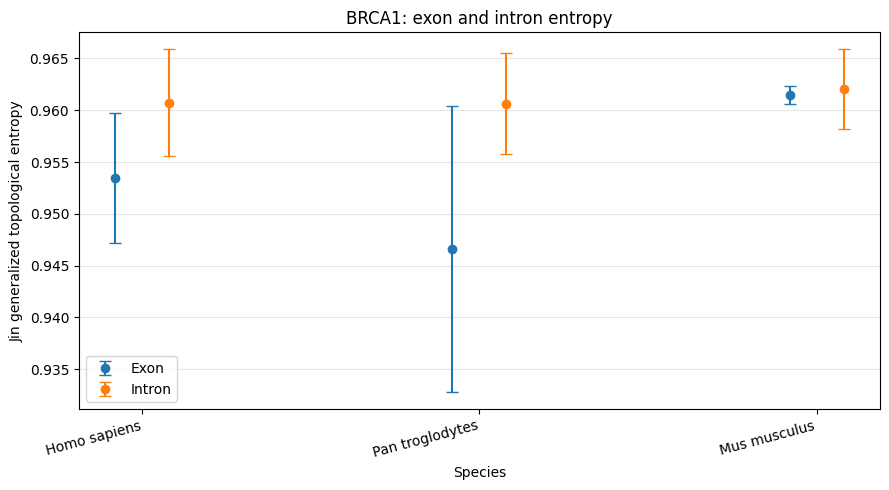

In [35]:
fig, ax = plot_entropy_by_species(
    summary_data=jin_summary_df,
    gene_name="BRCA1",
    save_path=(
        FIGURES_DIR
        / "brca1_species_summary.png"
    ),
)
plt.show()


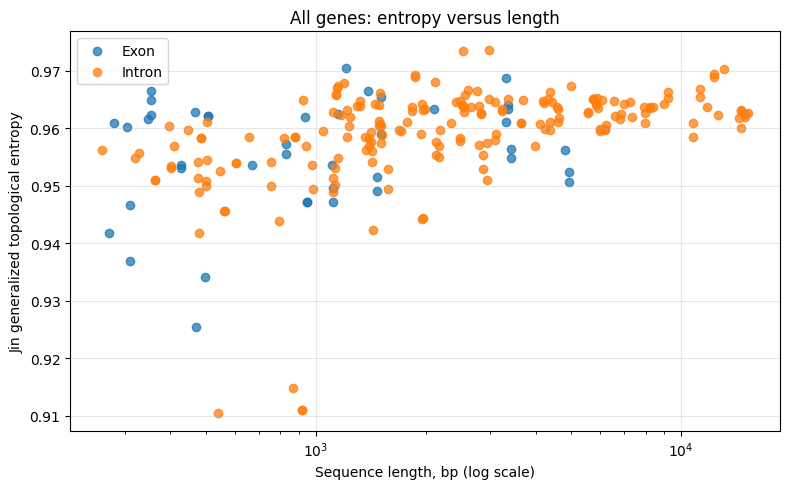

In [36]:
fig, ax = plot_entropy_vs_length(
    entropy_data=jin_analysis_df,
    gene_name=None,
    save_path=(
        FIGURES_DIR
        / "entropy_vs_length_all_genes.png"
    ),
)
plt.show()


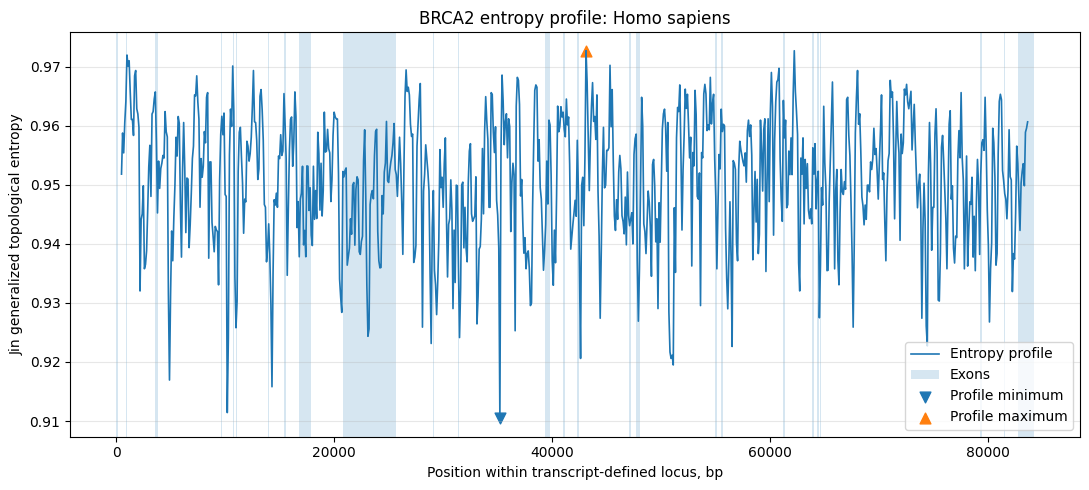

In [37]:
brca2_human_result = next(
    result
    for result in processed_datasets
    if result["dataset"]["gene"] == "BRCA2"
    and result["dataset"]["species_code"] == "hs"
)

fig, ax = plot_sliding_window_profile(
    profile_data=window_profile_df,
    locus_result=brca2_human_result,
    save_path=(
        FIGURES_DIR
        / "brca2_entropy_profile.png"
    ),
)
plt.show()


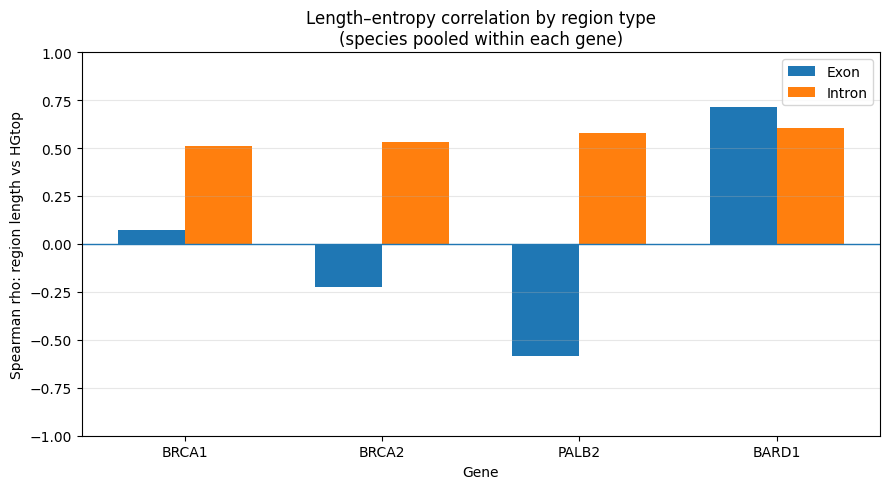

In [38]:
fig, ax = plot_correlation_summary(
    correlation_data=correlation_by_gene_region_df,
    save_path=(
        FIGURES_DIR
        / "length_entropy_correlations_by_region.png"
    ),
)
plt.show()


## 19. Export reproducible results

The main analytical tables are saved as CSV files so that the results can be
reviewed without rerunning the notebook.


In [39]:
output_tables = {
    "locus_summary.csv": locus_summary_df,
    "locus_validation.csv": validation_df,
    "jin_region_entropy_all.csv": jin_entropy_df,
    "jin_region_entropy_filtered.csv": jin_analysis_df,
    "koslicki_region_entropy_all.csv": koslicki_entropy_df,
    "koslicki_region_entropy_filtered.csv": (
        koslicki_analysis_df
    ),
    "entropy_summary.csv": jin_summary_df,
    "jin_exon_intron_comparison.csv": (
        jin_type_comparison_df
    ),
    "length_entropy_correlations_by_region.csv": (
        correlation_by_region_df
    ),
    "length_entropy_correlations_by_gene_region.csv": (
        correlation_by_gene_region_df
    ),
    "length_entropy_correlations_overall.csv": (
        correlation_overall_df
    ),
    "region_entropy_extremes.csv": (
        region_extremes_df
    ),
    "brca2_sensitivity_summary.csv": (
        brca2_sensitivity_summary_df
    ),
    "sliding_window_profiles.csv": (
        window_profile_df
    ),
    "sliding_window_summary.csv": (
        window_profile_summary_df
    ),
    "sliding_window_extremes.csv": (
        window_extremes_df
    ),
}

for filename, table in output_tables.items():
    table.to_csv(
        RESULTS_DIR / filename,
        index=False,
    )

print(
    f"Saved {len(output_tables)} result tables "
    f"to {RESULTS_DIR}."
)


Saved 16 result tables to /content/results.


## 20. Interpretation and limitations

The notebook reproduces four distinct parts of the diploma analysis:

- comparison of exon and intron entropy within the same orthologous gene;
- control of the relationship between **region length** and entropy, reported
  separately for exons and introns;
- identification of region-level and sliding-window minima and maxima;
- comparison of local entropy profiles across species.

The exon–intron comparison is based on descriptive statistics and
visualization. Spearman correlation is not used to correlate the categorical
labels “exon” and “intron”; it measures whether longer regions tend to have
different entropy values.

The strict `n_v >= 4` filter is retained to match the final diploma analysis.
Results should be interpreted cautiously because only a small number of exons
remain after filtering, and local low-entropy regions do not necessarily
coincide with exon boundaries.
